# Predicción del Tipo de Cambio USD/GEL con MLP
### Moneda: Lari Georgiano (GEL) — Georgia 🇬🇪

En este cuadernillo aplicaremos un `Perceptrón Multicapa` (`MLP`) para predecir el precio futuro del tipo de cambio entre el **Dólar Estadounidense (USD)** y el **Lari Georgiano (GEL)**, la moneda oficial de Georgia, un país ubicado entre Rusia y Turquía.

Nuestro dataset contiene registros diarios desde el año 2001 hasta 2020 con las columnas `Price`, `Open`, `High` y `Low`. El objetivo es predecir el precio de cierre (`Price`) del día siguiente a partir de una ventana de días anteriores.

Este es un problema de tipo **one-to-one**: entra una ventana de valores y sale un único valor predicho.

## Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = "cpu"
print("Dispositivo:", device)

Dispositivo: cpu


## Carga del Dataset

Cargamos el dataset desde la ruta local, lo ordenamos cronológicamente y mostramos información básica.

In [21]:
RUTA = r'C:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\P1\DATASET\DatasetLARI\USD_GEL Historical Data.csv'

df = pd.read_csv(RUTA)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Rango de fechas : {df["Date"].iloc[0].date()}  a  {df["Date"].iloc[-1].date()}')
print(f'Total de filas  : {len(df)}')
print(f'Columnas        : {list(df.columns)}')
df.head(11)

Rango de fechas : 2001-05-11  a  2020-10-27
Total de filas  : 4999
Columnas        : ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


,Date,Price,Open,High,Low,Vol.,Change %
0,2001-05-11,2.0550,2.0550,2.0550,2.0550,NaN,0.24%
1,2001-05-14,2.0570,2.0570,2.0570,2.0570,NaN,0.10%
2,2001-05-15,2.0595,2.0595,2.0595,2.0595,NaN,0.12%
3,2001-05-16,2.0650,2.0650,2.0650,2.0650,NaN,0.27%
4,2001-05-17,2.0700,2.0700,2.0700,2.0700,NaN,0.24%
5,2001-05-18,2.0670,2.0670,2.0670,2.0670,NaN,-0.14%
6,2001-05-21,2.0750,2.0750,2.0750,2.0750,NaN,0.39%
7,2001-05-22,2.0760,2.0760,2.0760,2.0760,NaN,0.05%
8,2001-05-23,2.0750,2.0750,2.0750,2.0750,NaN,-0.05%
9,2001-05-24,2.0670,2.0670,2.0670,2.0670,NaN,-0.39%


## Preprocesamiento

Seleccionamos las columnas `Price`, `Open`, `High` y `Low`. Normalizamos los valores entre 0 y 1 usando `MinMaxScaler`.

Separamos el **último mes** del dataset para usarlo como conjunto de test. El modelo nunca verá esos datos durante el entrenamiento.

In [3]:
FEATURES   = ['Price', 'Open', 'High', 'Low']
ULTIMO_MES = 22

df = df[['Date'] + FEATURES].dropna().reset_index(drop=True)

scaler     = MinMaxScaler()
datos_norm = scaler.fit_transform(df[FEATURES]).astype(np.float32)

datos_train_raw = datos_norm[:-ULTIMO_MES]
datos_test_raw  = datos_norm[-ULTIMO_MES:]
fechas_test     = df['Date'].iloc[-ULTIMO_MES:].values
precios_reales  = df['Price'].iloc[-ULTIMO_MES:].values

print(f'Datos para entrenamiento : {len(datos_train_raw)} dias')
print(f'Datos de test (1 mes)    : {len(datos_test_raw)} dias')

Datos para entrenamiento : 4977 dias
Datos de test (1 mes)    : 22 dias


In [4]:
print("Columnas usadas en el entrenamiento:\n")
print(f"{'Columna':<12} {'Min':>8} {'Max':>8} {'Media':>8} {'Std':>8}")
print("-" * 45)
for col in FEATURES:
    print(f"{col:<12} {df[col].min():>8.4f} {df[col].max():>8.4f} {df[col].mean():>8.4f} {df[col].std():>8.4f}")
print(f"\nTotal de filas  : {len(df)}")
print(f"Total columnas  : {len(FEATURES)}")
print(f"\nPrimeras 5 filas del dataset usado:")
df[['Date'] + FEATURES].head()

Columnas usadas en el entrenamiento:

Columna           Min      Max    Media      Std
---------------------------------------------
Price          1.3913   3.4496   2.0233   0.4265
Open           1.3913   3.4917   2.0288   0.4325
High           1.3913   3.5400   2.0337   0.4359
Low            1.3913   3.3806   2.0256   0.4272

Total de filas  : 4999
Total columnas  : 4

Primeras 5 filas del dataset usado:


,Date,Price,Open,High,Low
0,2001-05-11,2.0550,2.0550,2.0550,2.0550
1,2001-05-14,2.0570,2.0570,2.0570,2.0570
2,2001-05-15,2.0595,2.0595,2.0595,2.0595
3,2001-05-16,2.0650,2.0650,2.0650,2.0650
4,2001-05-17,2.0700,2.0700,2.0700,2.0700


Visualizamos el precio histórico completo y marcamos en rojo el mes que ocultamos al modelo.

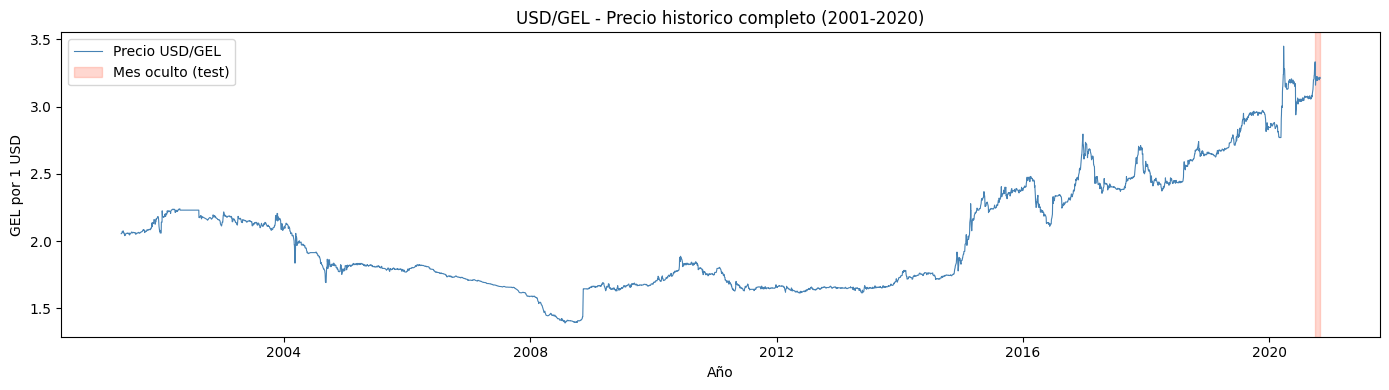

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8, label='Precio USD/GEL')
plt.axvspan(df['Date'].iloc[-ULTIMO_MES], df['Date'].iloc[-1], alpha=0.25, color='tomato', label='Mes oculto (test)')
plt.title('USD/GEL - Precio historico completo (2001-2020)')
plt.xlabel('Año')
plt.ylabel('GEL por 1 USD')
plt.legend()
plt.tight_layout()
plt.show()

## Ventanas Deslizantes (Sliding Window)

Para que el `MLP` pueda aprender patrones temporales, transformamos la serie en pares de ventanas. Usamos una ventana de `n_steps = 14` días para predecir el día 15.

```
Ventana 1: [d1, d2, ..., d14]  →  predice d15
Ventana 2: [d2, d3, ..., d15]  →  predice d16
Ventana 3: [d3, d4, ..., d16]  →  predice d17
```

Cada ventana se aplana en un vector antes de entrar al `MLP`.

In [6]:
n_steps = 14

def build_windows(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i : i + n_steps])
        y.append(data[i + n_steps, [0]])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = build_windows(datos_train_raw, n_steps)

split_train      = int(len(X_all) * 0.8)
X_train, y_train = X_all[:split_train], y_all[:split_train]
X_valid, y_valid = X_all[split_train:], y_all[split_train:]

X_test_raw     = np.concatenate([datos_train_raw[-n_steps:], datos_test_raw], axis=0)
X_test, y_test = build_windows(X_test_raw, n_steps)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape}  |  y_valid: {y_valid.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')

X_train: (3970, 14, 4)  |  y_train: (3970, 1)
X_valid: (993, 14, 4)  |  y_valid: (993, 1)
X_test : (22, 14, 4)   |  y_test : (22, 1)


## Dataset y DataLoader

In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = X
        self.y     = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval' : TimeSeriesDataset(X_valid, y_valid),
    'test' : TimeSeriesDataset(X_test,  train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

## Perceptrón Multicapa (MLP)

Definimos nuestro `MLP`. La entrada tiene `n_in = n_steps x n_features = 14 x 4 = 56` valores. El modelo cuenta con una capa oculta de 32 neuronas con activación `ReLU`, seguida de una capa de salida de 1 neurona.

In [8]:
class MLP(torch.nn.Module):
    def __init__(self, n_in=56, n_out=1):
        super().__init__()
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(n_in, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, n_out)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x

mlp = MLP()
mlp

MLP(
  (fc): Sequential(
    (0): Linear(in_features=56, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Entrenamiento

Utilizamos `backpropagation` con el optimizador `Adam` y la función de pérdida `MSELoss`. El **Early Stopping** detiene el entrenamiento si la pérdida de validación no mejora durante `patience` épocas y restaura los mejores pesos.

In [9]:
def fit(model, dataloader, epochs=500, lr=1e-3, patience=20, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    history   = {'train_loss': [], 'val_loss': []}
    mejor_val   = float('inf')
    sin_mejora  = 0
    mejor_pesos = None

    for epoch in tqdm(range(1, epochs + 1)):
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        t_mean = float(np.mean(train_loss))
        v_mean = float(np.mean(eval_loss))
        history['train_loss'].append(t_mean)
        history['val_loss'].append(v_mean)

        if verbose:
            print(f"Epoca {epoch:>3}  |  loss: {t_mean:.6f}  |  val_loss: {v_mean:.6f}")

        if v_mean < mejor_val:
            mejor_val   = v_mean
            sin_mejora  = 0
            mejor_pesos = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                print(f"\nEarly stopping en epoca {epoch} | mejor val_loss: {mejor_val:.6f}")
                break

    model.load_state_dict(mejor_pesos)
    return history


def predict(model, dataloader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dataloader:
            X = batch.to(device)
            preds.append(model(X).cpu())
    return torch.cat(preds, dim=0)


def desnormalizar(vals_norm):
    dummy = np.zeros((len(vals_norm), len(FEATURES)))
    dummy[:, 0] = vals_norm
    return scaler.inverse_transform(dummy)[:, 0]

In [10]:
history = fit(mlp, dataloader)

  1%|          | 6/500 [00:00<00:20, 23.91it/s]

Epoca   1  |  loss: 0.020019  |  val_loss: 0.003515
Epoca   2  |  loss: 0.000296  |  val_loss: 0.001111
Epoca   3  |  loss: 0.000125  |  val_loss: 0.000583
Epoca   4  |  loss: 0.000102  |  val_loss: 0.000526
Epoca   5  |  loss: 0.000100  |  val_loss: 0.000483
Epoca   6  |  loss: 0.000092  |  val_loss: 0.000423


  2%|▏         | 12/500 [00:00<00:19, 25.16it/s]

Epoca   7  |  loss: 0.000090  |  val_loss: 0.000417
Epoca   8  |  loss: 0.000079  |  val_loss: 0.000408
Epoca   9  |  loss: 0.000075  |  val_loss: 0.000353
Epoca  10  |  loss: 0.000072  |  val_loss: 0.000358
Epoca  11  |  loss: 0.000071  |  val_loss: 0.000609
Epoca  12  |  loss: 0.000079  |  val_loss: 0.000279


  4%|▎         | 18/500 [00:00<00:19, 25.30it/s]

...

Epoca  96  |  loss: 0.000035  |  val_loss: 0.000126
Epoca  97  |  loss: 0.000035  |  val_loss: 0.000191
Epoca  98  |  loss: 0.000031  |  val_loss: 0.000201
Epoca  99  |  loss: 0.000032  |  val_loss: 0.000139
Epoca 100  |  loss: 0.000031  |  val_loss: 0.000207
Epoca 101  |  loss: 0.000038  |  val_loss: 0.000288


 21%|██        | 105/500 [00:04<00:15, 25.25it/s]

Epoca 102  |  loss: 0.000040  |  val_loss: 0.000341
Epoca 103  |  loss: 0.000035  |  val_loss: 0.000125
Epoca 104  |  loss: 0.000039  |  val_loss: 0.000181
Epoca 105  |  loss: 0.000043  |  val_loss: 0.000200
Epoca 106  |  loss: 0.000036  |  val_loss: 0.000114


 22%|██▏       | 110/500 [00:04<00:15, 24.89it/s]

Epoca 107  |  loss: 0.000032  |  val_loss: 0.000147
Epoca 108  |  loss: 0.000033  |  val_loss: 0.000178
Epoca 109  |  loss: 0.000035  |  val_loss: 0.000157
Epoca 110  |  loss: 0.000031  |  val_loss: 0.000162
Epoca 111  |  loss: 0.000033  |  val_loss: 0.000230

Early stopping en epoca 111 | mejor val_loss: 0.000112


## Curva de Entrenamiento

Si ambas curvas bajan juntas el modelo está aprendiendo correctamente. Si la curva de validación sube mientras la de entrenamiento baja, hay sobreajuste.

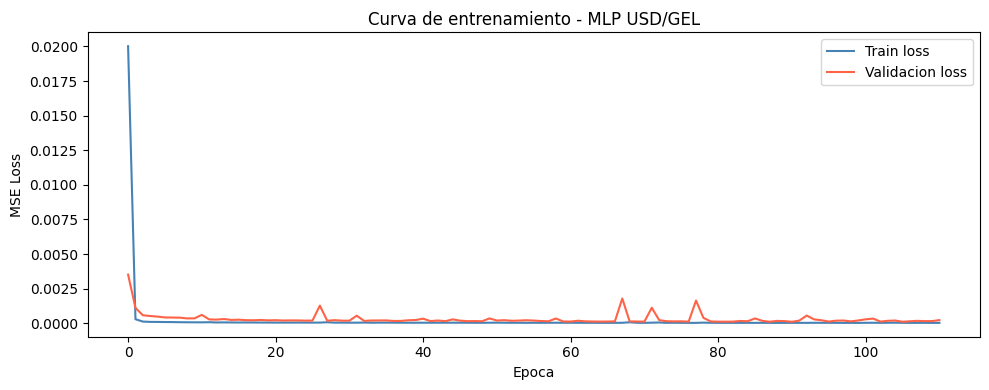

Epocas entrenadas : 111
Mejor val_loss    : 0.000112


In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train loss',      color='steelblue')
plt.plot(history['val_loss'],   label='Validacion loss', color='tomato')
plt.title('Curva de entrenamiento - MLP USD/GEL')
plt.xlabel('Epoca')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Epocas entrenadas : {len(history["train_loss"])}')
print(f'Mejor val_loss    : {min(history["val_loss"]):.6f}')

## Evaluacion - Ultimo Mes (Test)

Le pedimos al modelo que prediga los días del mes que ocultamos y comparamos con los valores reales.

In [12]:
y_pred        = predict(mlp, dataloader['test'])
y_pred_precio = desnormalizar(y_pred.numpy().flatten())
print('MSE:', mean_squared_error(precios_reales, y_pred_precio))
print('MAE:', np.mean(np.abs(precios_reales - y_pred_precio)))

MSE: 0.0013459254641242173
MAE: 0.021298642445152328


## Prediccion por Horizontes: 1 dia, 1 semana, 1 mes, 1 año

Usamos los últimos `n_steps` días como semilla. En cada paso, la predicción del día anterior se convierte en la entrada del siguiente.

In [13]:
def predecir_futuro(model, semilla, n_dias):
    model.eval()
    ventana = list(semilla.copy())
    preds   = []
    with torch.no_grad():
        for _ in range(n_dias):
            X    = torch.from_numpy(np.array(ventana[-n_steps:], dtype=np.float32)).unsqueeze(0).to(device)
            p    = model(X).item()
            preds.append(p)
            nuevo    = ventana[-1].copy()
            nuevo[0] = p
            ventana.append(nuevo)
    return desnormalizar(np.array(preds))

ultima_fecha = df['Date'].iloc[-1]
semilla      = datos_norm[-n_steps:]
horizontes   = {'1 dia': 1, '1 semana': 5, '1 mes': 22, '1 año': 252}

def fechas_futuras(n):
    return pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=n, freq='B')

print('Predicciones desde el ultimo dato del dataset:\n')
for nombre, n in horizontes.items():
    p = predecir_futuro(mlp, semilla, n)
    f = fechas_futuras(n)
    print(f'  {nombre:10s}  ->  {f[0].date()} al {f[-1].date()}  |  USD/GEL estimado: {p[-1]:.4f} GEL')

Predicciones desde el ultimo dato del dataset:

  1 dia       ->  2020-10-28 al 2020-10-28  |  USD/GEL estimado: 3.2102 GEL
  1 semana    ->  2020-10-28 al 2020-11-03  |  USD/GEL estimado: 3.2083 GEL
  1 mes       ->  2020-10-28 al 2020-11-26  |  USD/GEL estimado: 3.2073 GEL
  1 año       ->  2020-10-28 al 2021-10-14  |  USD/GEL estimado: 3.2068 GEL


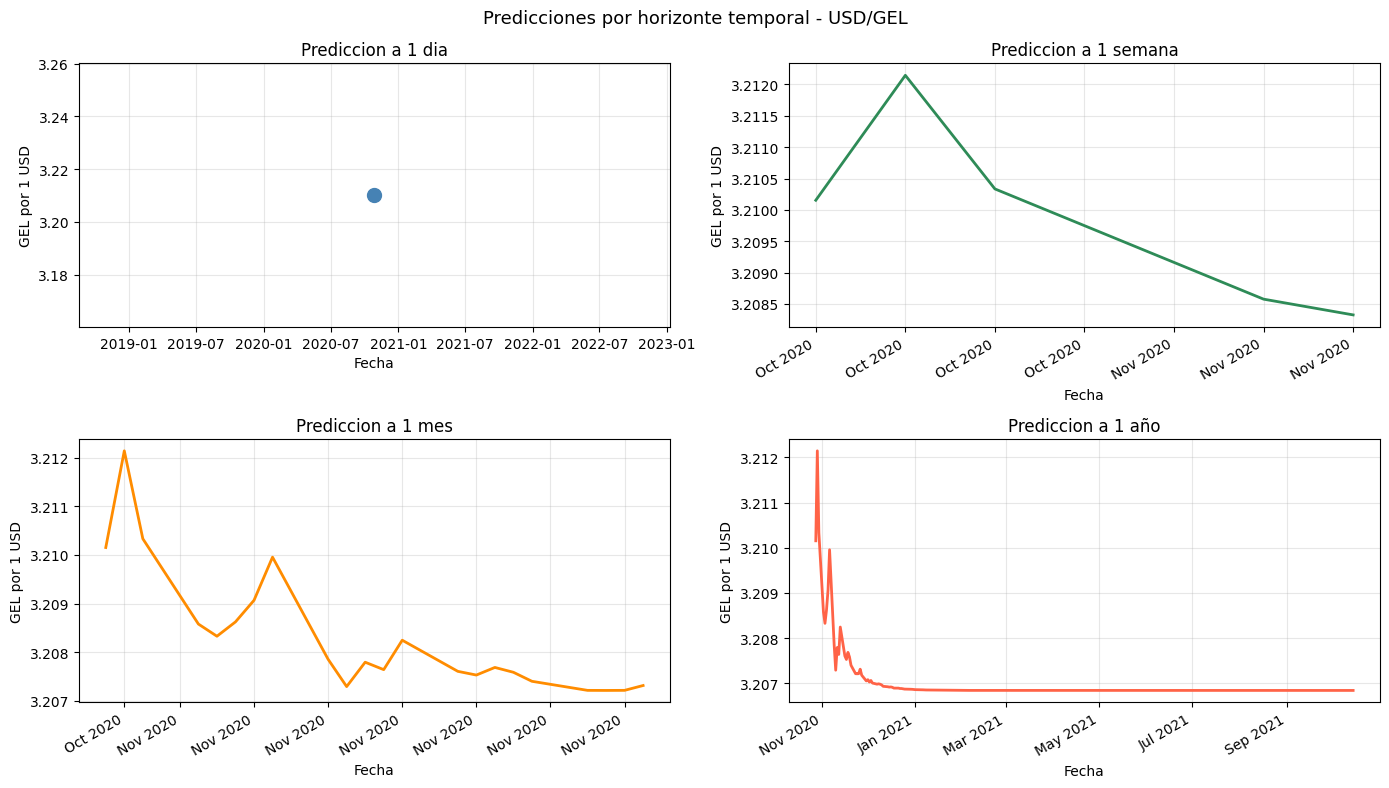

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Predicciones por horizonte temporal - USD/GEL', fontsize=13)
colores = ['steelblue', 'seagreen', 'darkorange', 'tomato']

for ax, (nombre, n), color in zip(axes.flatten(), horizontes.items(), colores):
    p = predecir_futuro(mlp, semilla, n)
    f = fechas_futuras(n)
    if n == 1:
        ax.scatter(f, p, color=color, s=100, zorder=5)
        ax.set_ylim(p[0] - 0.05, p[0] + 0.05)
    else:
        ax.plot(f, p, color=color, linewidth=2)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_title(f'Prediccion a {nombre}')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('GEL por 1 USD')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis Mes a Mes (2019 - 2020)

Visualizamos los datos reales del tipo de cambio mes a mes desde 2019.

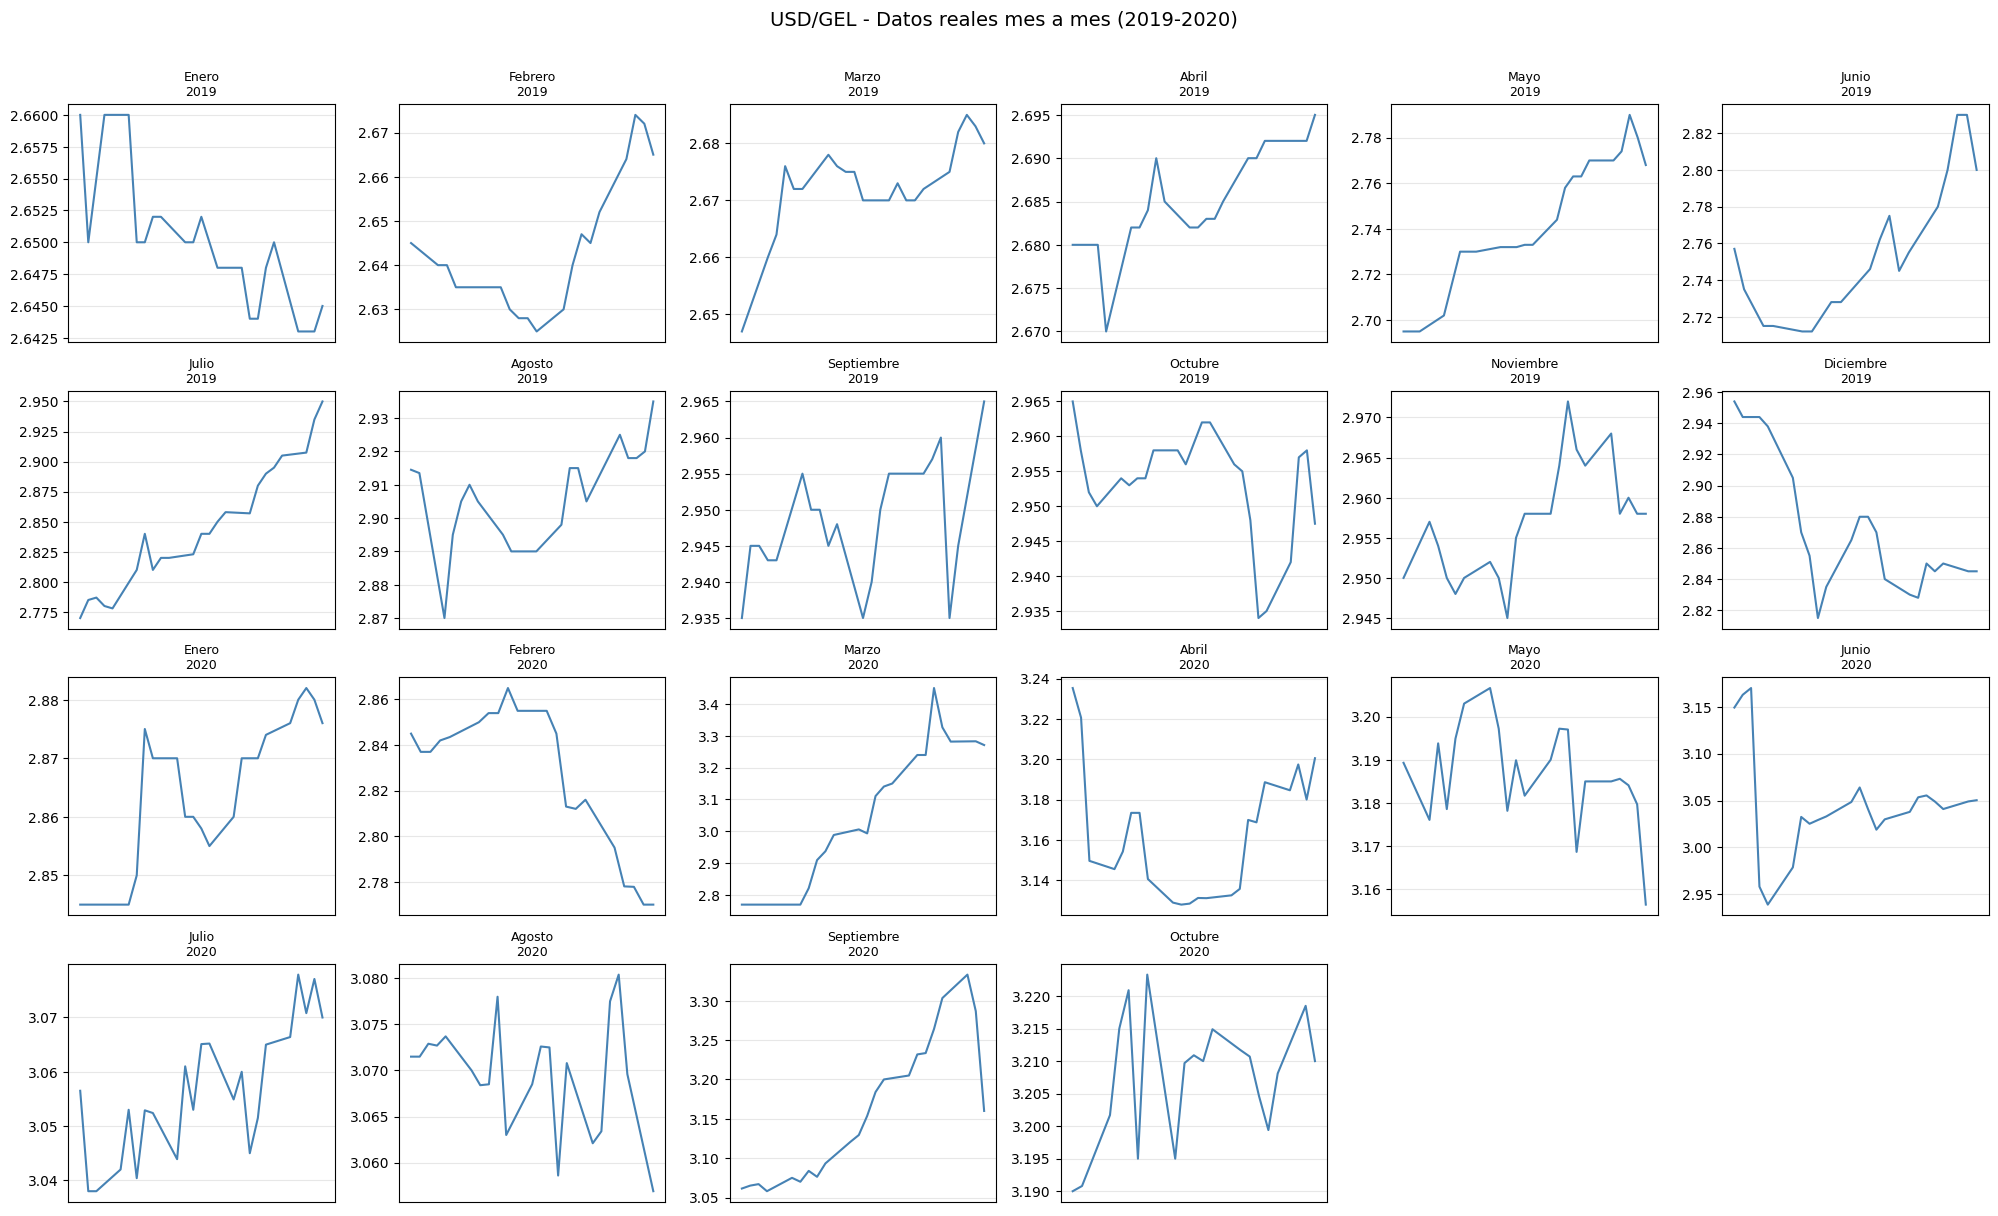

In [15]:
df_2019 = df[df['Date'].dt.year >= 2019].copy()

meses_es = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril',
            5:'Mayo', 6:'Junio', 7:'Julio', 8:'Agosto',
            9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

grupos = [(año, mes, grupo)
          for (año, mes), grupo in df_2019.groupby(
              [df_2019['Date'].dt.year, df_2019['Date'].dt.month])]

cols = 6
rows = -(-len(grupos) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3), sharey=False)
axes = axes.flatten()

for i, (año, mes, grupo) in enumerate(grupos):
    axes[i].plot(grupo['Date'], grupo['Price'], color='steelblue', linewidth=1.5)
    axes[i].set_title(f"{meses_es[mes]}\n{año}", fontsize=9)
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('USD/GEL - Datos reales mes a mes (2019-2020)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Grilla con Ultimo Mes Predicho

Mostramos la misma grilla pero el último mes es reemplazado por la predicción del modelo.

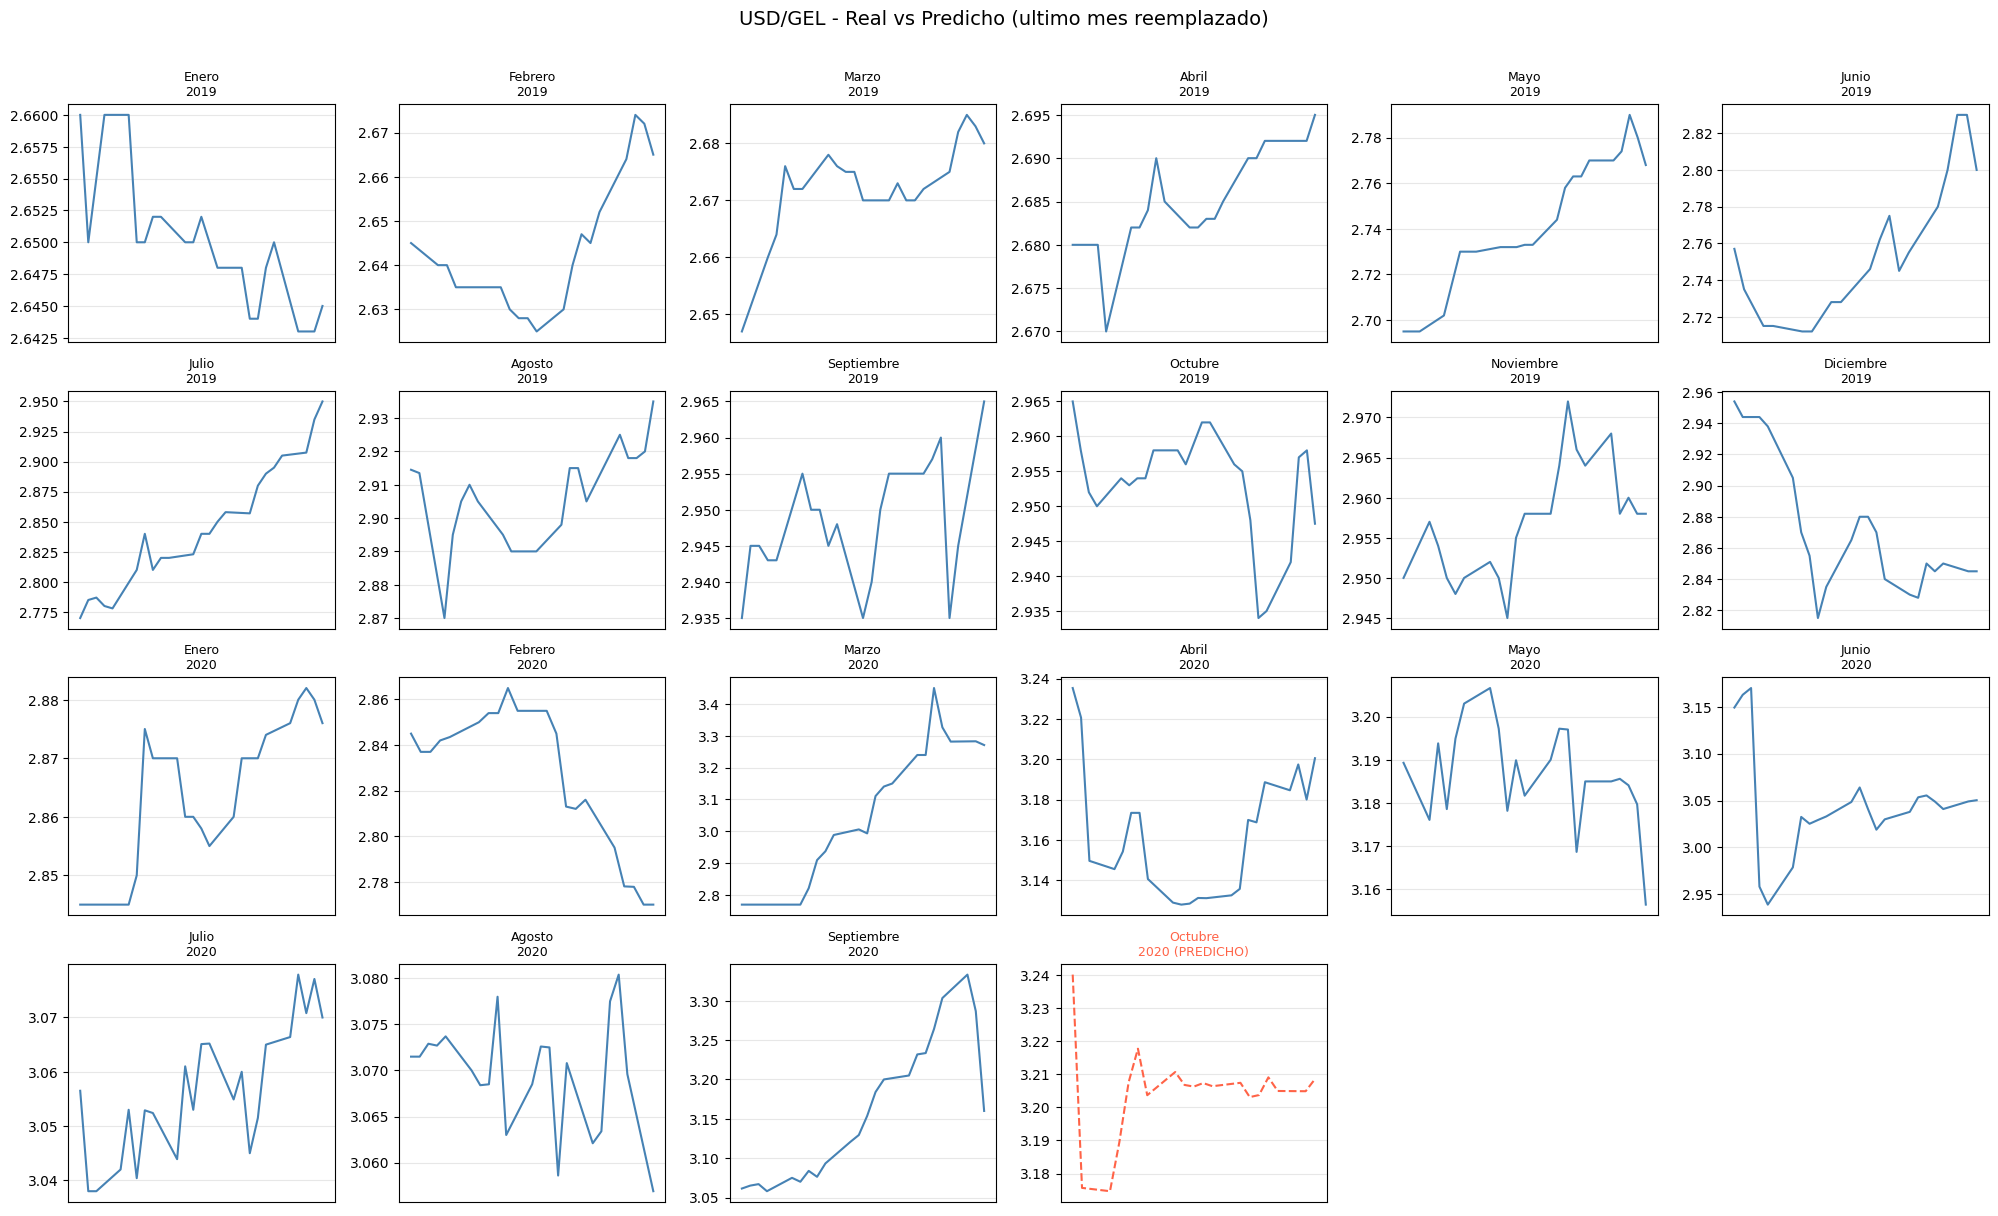

In [16]:
ultimo_año = df_2019['Date'].dt.year.iloc[-1]
ultimo_mes = df_2019['Date'].dt.month.iloc[-1]

mask           = pd.to_datetime(fechas_test).month == ultimo_mes
fechas_octubre = fechas_test[mask]
y_pred_octubre = y_pred_precio[mask]

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3), sharey=False)
axes = axes.flatten()

for i, (año, mes, grupo) in enumerate(grupos):
    if año == ultimo_año and mes == ultimo_mes:
        axes[i].plot(fechas_octubre, y_pred_octubre, color='tomato', linewidth=1.5, linestyle='--')
        axes[i].set_title(f"{meses_es[mes]}\n{año} (PREDICHO)", fontsize=9, color='tomato')
    else:
        axes[i].plot(grupo['Date'], grupo['Price'], color='steelblue', linewidth=1.5)
        axes[i].set_title(f"{meses_es[mes]}\n{año}", fontsize=9)
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('USD/GEL - Real vs Predicho (ultimo mes reemplazado)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Comparacion Real vs Predicho — Ultimo Mes

Comparamos directamente los precios reales y predichos del último mes.

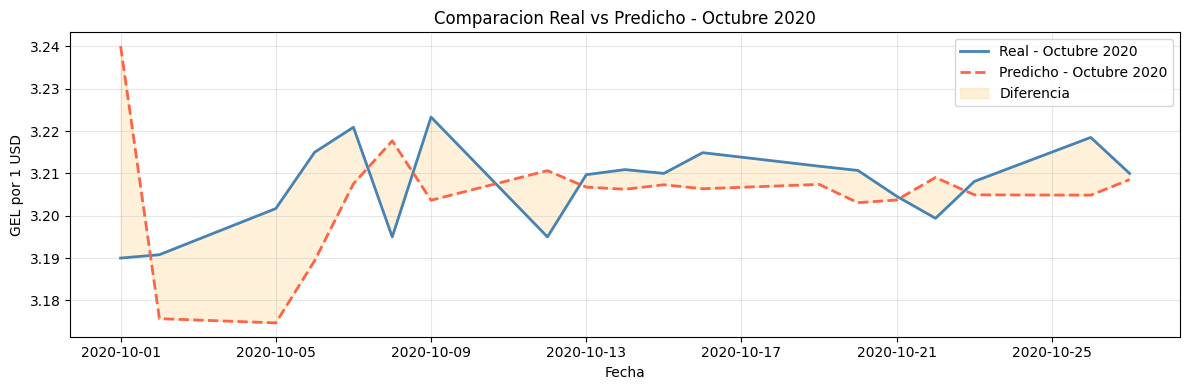

MAE  : 0.0131 GEL
RMSE : 0.0177 GEL
MSE  : 0.000312
MAPE : 0.41 %


In [17]:
precios_reales_mes = df[df['Date'].isin(fechas_octubre)]['Price'].values

plt.figure(figsize=(12, 4))
plt.plot(fechas_octubre, precios_reales_mes, color='steelblue', linewidth=2,
         label=f'Real - {meses_es[ultimo_mes]} {ultimo_año}')
plt.plot(fechas_octubre, y_pred_octubre,     color='tomato',    linewidth=2,
         linestyle='--', label=f'Predicho - {meses_es[ultimo_mes]} {ultimo_año}')
plt.fill_between(fechas_octubre, precios_reales_mes, y_pred_octubre,
                 alpha=0.15, color='orange', label='Diferencia')
plt.title(f'Comparacion Real vs Predicho - {meses_es[ultimo_mes]} {ultimo_año}')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(precios_reales_mes, y_pred_octubre))
mape = np.mean(np.abs((precios_reales_mes - y_pred_octubre) / precios_reales_mes)) * 100
print(f'MAE  : {np.mean(np.abs(precios_reales_mes - y_pred_octubre)):.4f} GEL')
print(f'RMSE : {rmse:.4f} GEL')
print(f'MSE  : {mean_squared_error(precios_reales_mes, y_pred_octubre):.6f}')
print(f'MAPE : {mape:.2f} %')

## Walk-Forward Validation — Sin Data Leakage (2019–2020)

Para cada mes desde Enero 2019 hasta el último mes del dataset:
1. Se entrena un modelo **nuevo** usando solo datos hasta el mes anterior
2. Se predice el mes actual con ventanas reales
3. Se compara predicción vs real

De esta forma el modelo **nunca conoce el futuro**.

In [18]:
from pandas.tseries.offsets import MonthBegin

meses_wf      = pd.date_range(start='2019-01-01', end=df['Date'].iloc[-1], freq='MS')
resultados_wf = []

print(f'Walk-Forward: {len(meses_wf)} meses a evaluar')
print('Esto puede tardar unos minutos...\n')

for mes_inicio in meses_wf:
    mes_fin  = mes_inicio + MonthBegin(1)
    mask_mes = (df['Date'] >= mes_inicio) & (df['Date'] < mes_fin)
    df_mes   = df[mask_mes]
    if len(df_mes) == 0:
        continue

    df_anterior = df[df['Date'] < mes_inicio]
    if len(df_anterior) < n_steps + 10:
        continue

    scaler_mes = MinMaxScaler()
    datos_ant  = scaler_mes.fit_transform(df_anterior[FEATURES]).astype(np.float32)
    datos_mes  = scaler_mes.transform(df_mes[FEATURES]).astype(np.float32)

    X_w, y_w = build_windows(datos_ant, n_steps)
    if len(X_w) < 20:
        continue
    split  = int(len(X_w) * 0.8)
    dl_mes = {
        'train': DataLoader(TimeSeriesDataset(X_w[:split], y_w[:split]), shuffle=True,  batch_size=64),
        'eval' : DataLoader(TimeSeriesDataset(X_w[split:], y_w[split:]), shuffle=False, batch_size=64),
    }

    mlp_mes = MLP()
    fit(mlp_mes, dl_mes, epochs=300, lr=1e-3, patience=15, verbose=False)

    datos_completos = np.concatenate([datos_ant, datos_mes], axis=0)
    idx_inicio      = len(datos_ant)

    X_pred = np.array([
        datos_completos[i - n_steps : i]
        for i in range(idx_inicio, idx_inicio + len(df_mes))
    ], dtype=np.float32)

    mlp_mes.eval()
    with torch.no_grad():
        p_norm = mlp_mes(torch.from_numpy(X_pred).to(device)).cpu().numpy().flatten()

    def desn_mes(vals):
        d = np.zeros((len(vals), len(FEATURES)))
        d[:, 0] = vals
        return scaler_mes.inverse_transform(d)[:, 0]

    p      = desn_mes(p_norm)
    reales = df_mes['Price'].values

    mae_mes  = np.mean(np.abs(reales - p))
    rmse_mes = np.sqrt(mean_squared_error(reales, p))
    mape_mes = np.mean(np.abs((reales - p) / reales)) * 100

    resultados_wf.append({
        'Mes'    : mes_inicio.strftime('%b %Y'),
        'Año'    : mes_inicio.year,
        'N_dias' : len(df_mes),
        'MAE'    : round(mae_mes,  4),
        'RMSE'   : round(rmse_mes, 4),
        'MAPE'   : round(mape_mes, 2),
        'reales' : reales,
        'preds'  : p,
        'fechas' : df_mes['Date'].values
    })
    print(f'  {mes_inicio.strftime("%b %Y")} OK  MAPE: {mape_mes:.2f}%')

df_resultados = pd.DataFrame(resultados_wf)[['Mes','Año','N_dias','MAE','RMSE','MAPE']]
print(f'\nMAE  promedio : {df_resultados["MAE"].mean():.4f} GEL')
print(f'RMSE promedio : {df_resultados["RMSE"].mean():.4f} GEL')
print(f'MAPE promedio : {df_resultados["MAPE"].mean():.2f} %')
print()
print(df_resultados.to_string(index=False))

Walk-Forward: 22 meses a evaluar
Esto puede tardar unos minutos...



 36%|███▌      | 107/300 [00:04<00:07, 25.83it/s]



Early stopping en epoca 108 | mejor val_loss: 0.000179
  Jan 2019 OK  MAPE: 0.13%


 25%|██▌       | 75/300 [00:02<00:08, 26.08it/s]



Early stopping en epoca 76 | mejor val_loss: 0.000239
  Feb 2019 OK  MAPE: 0.36%


...


Early stopping en epoca 116 | mejor val_loss: 0.000105
  Aug 2020 OK  MAPE: 0.24%


 15%|█▌        | 46/300 [00:01<00:10, 23.16it/s]



Early stopping en epoca 47 | mejor val_loss: 0.000276
  Sep 2020 OK  MAPE: 2.31%


 21%|██▏       | 64/300 [00:02<00:10, 22.70it/s]


Early stopping en epoca 65 | mejor val_loss: 0.000154
  Oct 2020 OK  MAPE: 0.72%

MAE  promedio : 0.0199 GEL
RMSE promedio : 0.0241 GEL
MAPE promedio : 0.66 %

     Mes  Año  N_dias    MAE   RMSE  MAPE
Jan 2019 2019      23 0.0034 0.0044  0.13
Feb 2019 2019      20 0.0094 0.0128  0.36
Mar 2019 2019      21 0.0062 0.0080  0.23
Apr 2019 2019      22 0.0034 0.0043  0.13
May 2019 2019      23 0.0095 0.0121  0.35
Jun 2019 2019      20 0.0166 0.0203  0.60
Jul 2019 2019      23 0.0192 0.0232  0.67
Aug 2019 2019      22 0.0106 0.0142  0.37
Sep 2019 2019      21 0.0086 0.0107  0.29
Oct 2019 2019      23 0.0361 0.0369  1.22
Nov 2019 2019      21 0.0147 0.0155  0.50
Dec 2019 2019      22 0.0190 0.0252  0.66
Jan 2020 2020      23 0.0067 0.0089  0.23
Feb 2020 2020      20 0.0183 0.0227  0.65
Mar 2020 2020      22 0.0448 0.0620  1.43
Apr 2020 2020      22 0.0232 0.0282  0.73
May 2020 2020      21 0.0442 0.0463  1.39
Jun 2020 2020      22 0.0323 0.0526  1.07
Jul 2020 2020      23 0.0078 0.0095  0.25

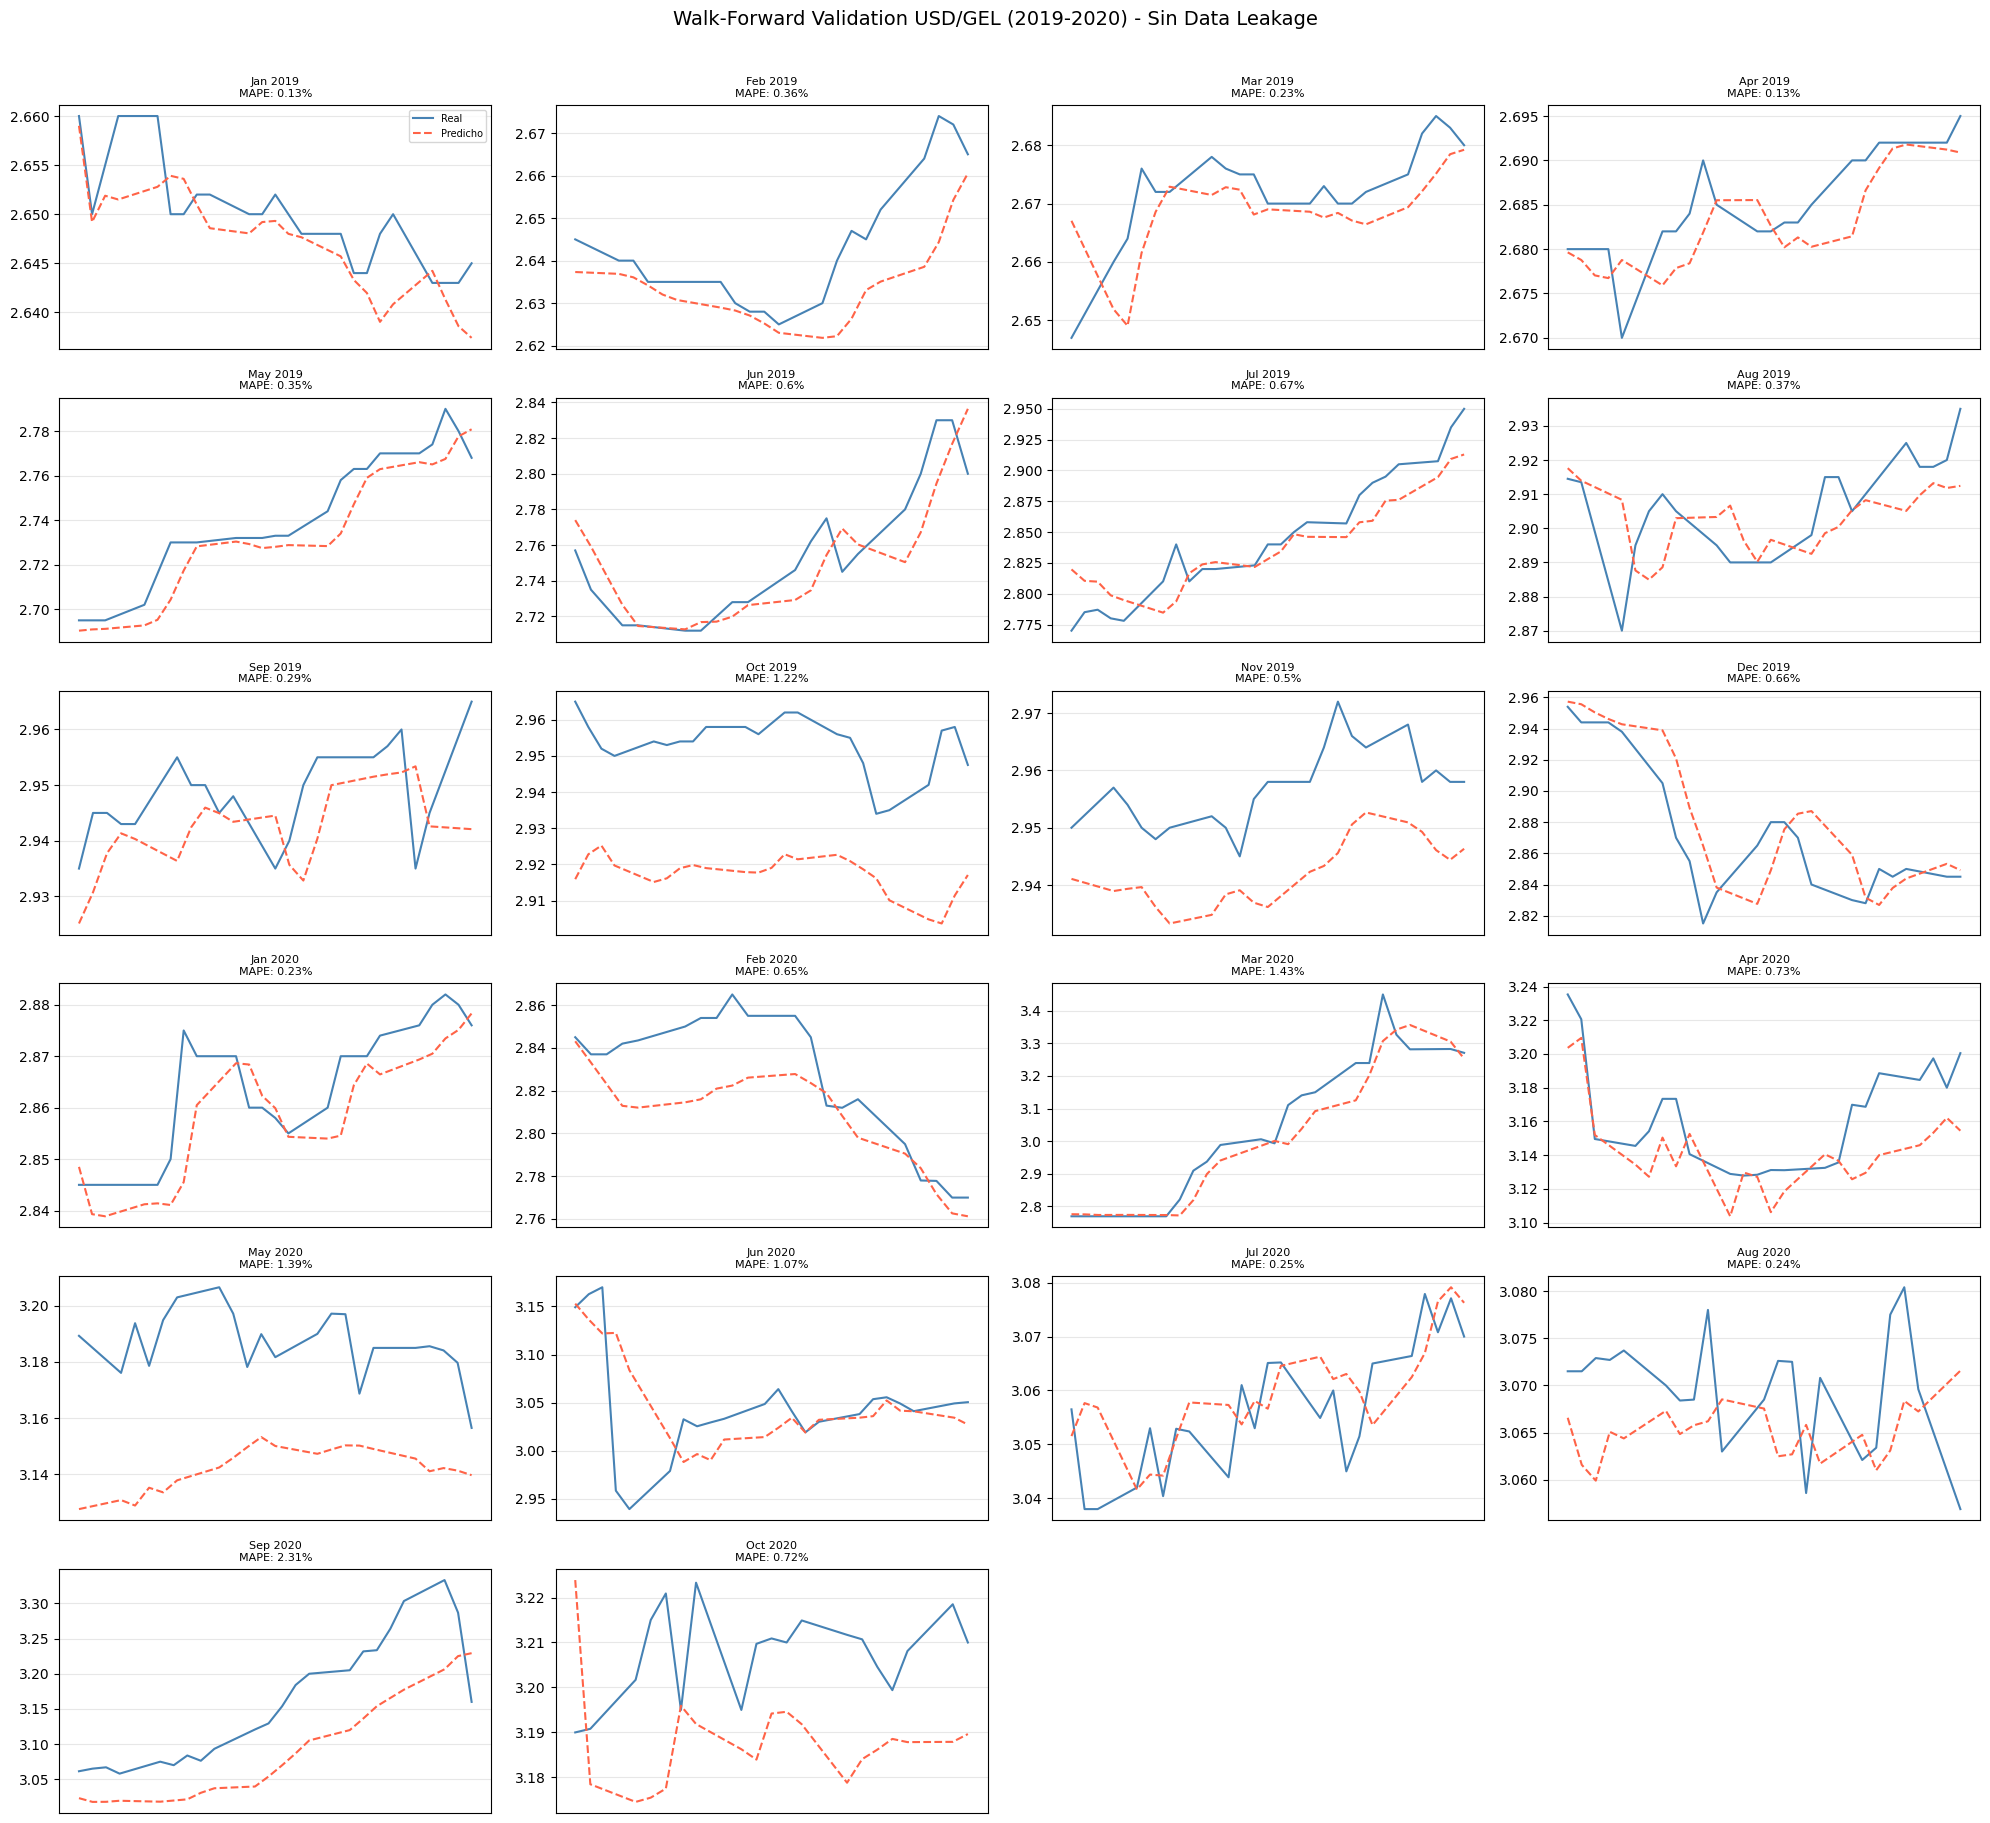

In [19]:
cols_wf = 4
rows_wf = -(-len(resultados_wf) // cols_wf)

fig, axes = plt.subplots(rows_wf, cols_wf, figsize=(20, rows_wf * 3))
axes = axes.flatten()

for i, res in enumerate(resultados_wf):
    axes[i].plot(res['fechas'], res['reales'], color='steelblue', linewidth=1.5, label='Real')
    axes[i].plot(res['fechas'], res['preds'],  color='tomato',    linewidth=1.5, linestyle='--', label='Predicho')
    axes[i].set_title(f"{res['Mes']}\nMAPE: {res['MAPE']}%", fontsize=8)
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3)

axes[0].legend(fontsize=7)

for j in range(len(resultados_wf), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Walk-Forward Validation USD/GEL (2019-2020) - Sin Data Leakage', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Resumen de Resultados

In [20]:
rmse_final = np.sqrt(mean_squared_error(precios_reales_mes, y_pred_octubre))
mape_final = np.mean(np.abs((precios_reales_mes - y_pred_octubre) / precios_reales_mes)) * 100

print("=" * 55)
print("        RESUMEN DE RESULTADOS - MLP USD/GEL")
print("=" * 55)

print(f"\nCONFIGURACION")
print(f"   Ventana (n_steps)   : {n_steps} dias")
print(f"   Features            : {FEATURES}")
print(f"   Dispositivo         : {device}")

print(f"\nENTRENAMIENTO")
print(f"   Epocas entrenadas   : {len(history['train_loss'])}")
print(f"   Mejor train_loss    : {min(history['train_loss']):.6f}")
print(f"   Mejor val_loss      : {min(history['val_loss']):.6f}")

print(f"\nEVALUACION - ULTIMO MES ({meses_es[ultimo_mes]} {ultimo_año})")
print(f"   MAE                 : {np.mean(np.abs(precios_reales_mes - y_pred_octubre)):.4f} GEL")
print(f"   RMSE                : {rmse_final:.4f} GEL")
print(f"   MSE                 : {mean_squared_error(precios_reales_mes, y_pred_octubre):.6f}")
print(f"   MAPE                : {mape_final:.2f} %")
print(f"   Precio real min     : {precios_reales_mes.min():.4f}")
print(f"   Precio real max     : {precios_reales_mes.max():.4f}")
print(f"   Precio pred min     : {y_pred_octubre.min():.4f}")
print(f"   Precio pred max     : {y_pred_octubre.max():.4f}")

print(f"\nPREDICCIONES FUTURAS")
for nombre, n in horizontes.items():
    p = predecir_futuro(mlp, semilla, n)
    f = fechas_futuras(n)
    print(f"   {nombre:10s}  ->  {f[-1].date()}  |  {p[-1]:.4f} GEL")

print(f"\nWALK-FORWARD 2019-2020")
print(f"   MAE  promedio : {df_resultados['MAE'].mean():.4f} GEL")
print(f"   RMSE promedio : {df_resultados['RMSE'].mean():.4f} GEL")
print(f"   MAPE promedio : {df_resultados['MAPE'].mean():.2f} %")

print("\n" + "=" * 55)

        RESUMEN DE RESULTADOS - MLP USD/GEL

CONFIGURACION
   Ventana (n_steps)   : 14 dias
   Features            : ['Price', 'Open', 'High', 'Low']
   Dispositivo         : cpu

ENTRENAMIENTO
   Epocas entrenadas   : 111
   Mejor train_loss    : 0.000031
   Mejor val_loss      : 0.000112

EVALUACION - ULTIMO MES (Octubre 2020)
   MAE                 : 0.0131 GEL
   RMSE                : 0.0177 GEL
   MSE                 : 0.000312
   MAPE                : 0.41 %
   Precio real min     : 3.1900
   Precio real max     : 3.2233
   Precio pred min     : 3.1747
   Precio pred max     : 3.2401

PREDICCIONES FUTURAS
   1 dia       ->  2020-10-28  |  3.2102 GEL
   1 semana    ->  2020-11-03  |  3.2083 GEL
   1 mes       ->  2020-11-26  |  3.2073 GEL
   1 año       ->  2021-10-14  |  3.2068 GEL

WALK-FORWARD 2019-2020
   MAE  promedio : 0.0199 GEL
   RMSE promedio : 0.0241 GEL
   MAPE promedio : 0.66 %



## Resumen Final

En este cuadernillo hemos entrenado un `MLP` para predecir el tipo de cambio USD/GEL usando una ventana deslizante de 14 días. El modelo recibe todos los valores de la ventana a la vez y produce un único valor predicho (arquitectura **one-to-one**).

| Horizonte | Confiabilidad | Razon |
|---|---|---|
| 1 dia    | Alta    | Ventana reciente, poco error acumulado |
| 1 semana | Media   | El error empieza a propagarse |
| 1 mes    | Regular | Cada prediccion alimenta la siguiente |
| 1 año    | Baja    | El MLP no captura tendencias de largo plazo |

El Walk-Forward Validation demuestra el comportamiento real del modelo mes a mes sin data leakage. Los meses con mayor error (Mar-Abr 2020) coinciden con el inicio del COVID-19, un evento sin precedentes que ningun modelo predictivo entrenado con datos historicos normales podria anticipar.

Para horizontes largos, arquitecturas como `LSTM` o `Transformer` son mas adecuadas.